In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#2b2b2b',     # fondo exterior
    'axes.facecolor':   '#2b2b2b',     # fondo del área del gráfico
    'axes.edgecolor':   '#cccccc',     # borde de los ejes
    'axes.labelcolor':  '#cccccc',     # etiquetas de los ejes
    'xtick.color':      '#cccccc',     # color de los números en el eje X
    'ytick.color':      '#cccccc',     # color de los números en el eje Y
    'text.color':       '#cccccc',     # color del título y textos
    'grid.color':       '#444444',     # color de la grilla
})

# Grilla 5x5
n = 5
states = [(i, j) for i in range(n) for j in range(n)]

# Mapeo de estado a índice
state_to_idx = {s: i for i, s in enumerate(states)}

# Vector de características φ(s): one-hot para cada celda
phi = np.eye(len(states))  # matriz identidad: cada estado es un vector único

# Trayectoria del experto (hardcodeada)
expert_traj = [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)]  # va en forma de L hasta el objetivo

# Cálculo de μ_E (expectativa de características del experto)
mu_E = np.zeros(len(states))
for s in expert_traj:
    idx = state_to_idx[s]
    mu_E += phi[idx]
mu_E /= len(expert_traj)

In [ ]:
# Acciones posibles: arriba, abajo, izq, der
actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

def is_valid(pos):
    return 0 <= pos[0] < n and 0 <= pos[1] < n

def get_next_states(s):
    """Devuelve lista de estados vecinos válidos"""
    vecinos = []
    for a in actions:
        nx, ny = s[0] + a[0], s[1] + a[1]
        if is_valid((nx, ny)):
            vecinos.append((nx, ny))
    return vecinos

In [ ]:
def value_iteration(w, gamma=0.9, theta=1e-3):
    """Retorna V y política óptima para R(s) = wᵗϕ(s)"""
    V = np.zeros(len(states))
    R = phi @ w  # R(s) = wᵗϕ(s)

    while True:
        delta = 0
        for s in states:
            s_idx = state_to_idx[s]
            vecinos = get_next_states(s)
            if not vecinos:
                continue
            v = V[s_idx]
            V[s_idx] = R[s_idx] + gamma * max(V[state_to_idx[s2]] for s2 in vecinos)
            delta = max(delta, abs(v - V[s_idx]))
        if delta < theta:
            break

    # Política derivada: para cada estado, elegir vecino con mejor V
    policy = {}
    for s in states:
        vecinos = get_next_states(s)
        if not vecinos:
            continue
        best = max(vecinos, key=lambda s2: V[state_to_idx[s2]])
        policy[s] = best
    return V, policy

In [ ]:
def compute_mu_pi(policy, start, steps=5):
    """Simula una trayectoria desde start con la política dada"""
    mu = np.zeros(len(states))
    s = start
    for _ in range(steps):
        idx = state_to_idx[s]
        mu += phi[idx]
        s = policy.get(s, s)  # seguir política o quedarse
    return mu / steps

# Inicializar w aleatorio
w = np.random.rand(len(states))
w /= np.linalg.norm(w)

# Entrenar w para que mu_pi se aproxime a mu_E
alpha = 0.1  # tasa de aprendizaje
for iteration in range(100):
    _, policy = value_iteration(w)
    mu_pi = compute_mu_pi(policy, start=(0, 0))  # mismo punto de inicio
    grad = mu_E - mu_pi
    w += alpha * grad
    w /= np.linalg.norm(w)  # normalizar

In [ ]:
_, final_policy = value_iteration(w)

print("Política aprendida (flechas):")
arrow = {
    (-1, 0): '↑', (1, 0): '↓', (0, -1): '←', (0, 1): '→'
}
for i in range(n):
    row = ""
    for j in range(n):
        s = (i, j)
        if s in final_policy:
            dx = final_policy[s][0] - i
            dy = final_policy[s][1] - j
            row += arrow.get((dx, dy), '·') + " "
        else:
            row += "· "
    print(row)


Política aprendida (flechas):
↓ → ↓ ↓ ↓ 
↓ → ↓ ← ← 
→ → ↓ ← ↓ 
→ → ↑ ← ← 
↑ ↑ ↑ ↑ ← 


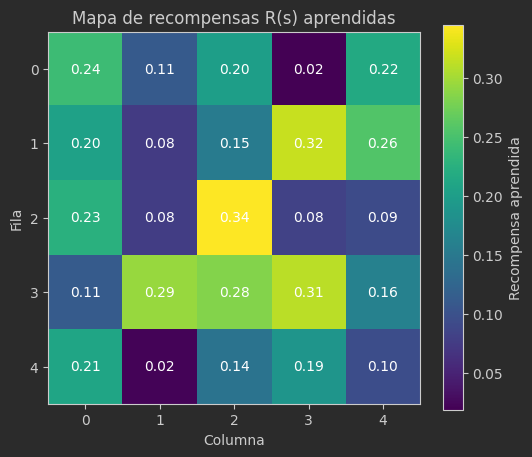

In [ ]:
import matplotlib.pyplot as plt

# Cálculo de la recompensa para cada estado
R = phi @ w  # R(s) = wᵗϕ(s)
reward_grid = R.reshape((n, n))

# Visualizar como mapa de calor
plt.figure(figsize=(6, 5))
plt.imshow(reward_grid, cmap='viridis', origin='upper')
plt.colorbar(label='Recompensa aprendida')
plt.title('Mapa de recompensas R(s) aprendidas')
plt.xlabel('Columna')
plt.ylabel('Fila')

# Anotar los valores en cada celda
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{reward_grid[i, j]:.2f}", ha='center', va='center', color='white')

plt.show()